In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

df = pd.read_csv("online_shoppers_intention.csv")

In [10]:
features = [
    'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
    'TrafficType', 'VisitorType', 'Weekend', 'SpecialDay', 'Month'
]
target = 'Revenue'

X = df[features]
y = df[target]


In [11]:
# Encode categorical features
X = X.copy()
X['Weekend'] = X['Weekend'].astype(int)
X['VisitorType'] = LabelEncoder().fit_transform(X['VisitorType'])  # 0=New, 1=Other, 2=Returning
X['Month'] = LabelEncoder().fit_transform(X['Month'])  # Jan-Dec => 0-11

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numeric features
numeric_features = ['ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features)],
    remainder='passthrough'
)


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [13]:
model_results = {}
best_model = None
best_score = 0

for name, model_instance in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_instance)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(model_instance, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    model_results[name] = {
        'Accuracy': acc,
        'F1 Score': f1,
        'ROC AUC': auc,
        'Pipeline': pipeline
    }

    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}, ROC AUC: {auc:.4f}" if auc else f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

    if auc and auc > best_score:
        best_model = pipeline
        best_score = auc


Logistic Regression Results:
              precision    recall  f1-score   support

       False       0.90      0.98      0.94      2084
        True       0.76      0.41      0.53       382

    accuracy                           0.89      2466
   macro avg       0.83      0.69      0.73      2466
weighted avg       0.88      0.89      0.87      2466

Accuracy: 0.8889, F1 Score: 0.5324, ROC AUC: 0.8916

Random Forest Results:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2084
        True       0.69      0.60      0.65       382

    accuracy                           0.90      2466
   macro avg       0.81      0.78      0.79      2466
weighted avg       0.89      0.90      0.89      2466

Accuracy: 0.8974, F1 Score: 0.6462, ROC AUC: 0.9262

SVM Results:
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      2084
        True       0.74      0.48      0.58       382

    accura

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:19:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


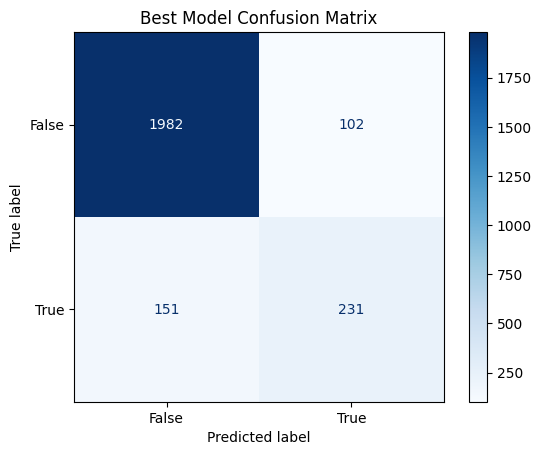

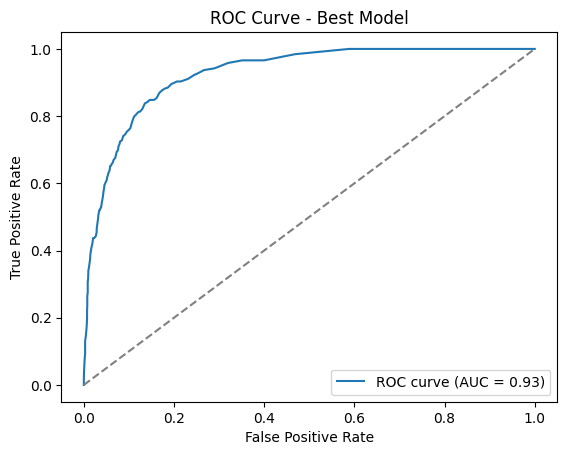

In [14]:
if best_model:
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
    disp.plot(cmap='Blues')
    plt.title("Best Model Confusion Matrix")
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Best Model")
    plt.legend(loc="lower right")
    plt.show()